# Logistic regresstion

In [10]:
# import python libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# step 2: load the dataset
df = pd.read_csv(r"Hospital_Patient_Dataset.csv")

In [12]:
# step 3: check head
df.head()


,Patient_ID,Age,Gender,Diagnosis,Admission_Date,Discharge_Date,Doctor_Assigned,Bill_Amount,Insurance_Covered
0,PAT3000,17,Female,Diabetes,2023-06-11,2023-06-20,Dr. Rao,18709,No
1,PAT3001,50,Male,Heart Disease,2023-03-22,2023-03-31,Dr. Khan,45682,No
2,PAT3002,40,Female,Flu,2023-12-25,2023-12-29,Dr. Khan,9998,Yes
3,PAT3003,58,Male,Heart Disease,2023-06-24,2023-06-25,Dr. Patel,29906,No
4,PAT3004,75,Female,Flu,2023-02-05,2023-02-12,Dr. Sharma,36490,Yes


In [13]:
# step 4: check tail
df.tail()

,Patient_ID,Age,Gender,Diagnosis,Admission_Date,Discharge_Date,Doctor_Assigned,Bill_Amount,Insurance_Covered
495,PAT3495,85,Female,Hypertension,2023-01-25,2023-02-03,Dr. Patel,27872,Yes
496,PAT3496,56,Female,Diabetes,2023-09-29,2023-09-30,Dr. Sharma,42708,Yes
497,PAT3497,68,Male,Heart Disease,2023-02-09,2023-02-11,Dr. Khan,42093,No
498,PAT3498,44,Female,Hypertension,2023-04-29,2023-05-06,Dr. Rao,21800,No
499,PAT3499,31,Male,Hypertension,2023-02-12,2023-02-14,Dr. Patel,44397,Yes


In [14]:
# step 5: check the number of rows and number of columns
print("Number of rows:",df.shape[0])
print("="*100)
print("Number of columns:",df.shape[1])



Number of rows: 500
Number of columns: 9


In [15]:
# step 6: check the columns 
for i in df.columns:
    print(i)
    

Patient_ID
Age
Gender
Diagnosis
Admission_Date
Discharge_Date
Doctor_Assigned
Bill_Amount
Insurance_Covered


In [16]:
# step 7: check information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         500 non-null    object
 1   Age                500 non-null    int64 
 2   Gender             500 non-null    object
 3   Diagnosis          500 non-null    object
 4   Admission_Date     500 non-null    object
 5   Discharge_Date     500 non-null    object
 6   Doctor_Assigned    500 non-null    object
 7   Bill_Amount        500 non-null    int64 
 8   Insurance_Covered  500 non-null    object
dtypes: int64(2), object(7)
memory usage: 35.3+ KB


In [17]:
# step 8: check missing values in tataset
print("Number of missing values in the dataset:",df.isna().sum().sum())
print("="*100)

Number of missing values in the dataset: 0


In [18]:
# step 9: check duplicate rows count 
print("Duplicate rows:",df.duplicated().sum())
print("="*100)

Duplicate rows: 0


In [19]:
# step 10: descride the information

df.describe()

,Age,Bill_Amount
count,500.000000,500.000000
mean,44.394000,26230.642000
std,26.029172,14091.132927
min,1.000000,1021.000000
25%,21.000000,14331.000000
50%,44.000000,26600.500000
75%,68.000000,38283.500000
max,89.000000,49877.000000


<Axes: >

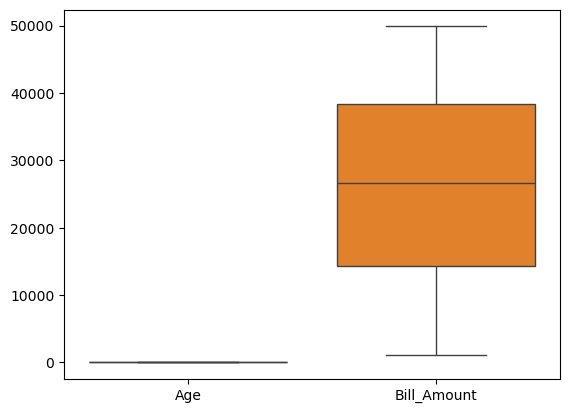

In [20]:
# step 11: check the outliers 
sns.boxplot(df)

In [21]:
# step 12: Drop patient_ID
df = df.drop("Patient_ID", axis=1)

In [22]:
# step 13: Find the length of stay
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

df["Length_of_Stay"] = (
    df["Discharge_Date"] - df["Admission_Date"]
).dt.days

# drop the original columns
df = df.drop(
    ["Admission_Date", "Discharge_Date"],
    axis=1
)

In [23]:
pd.get_dummies(
    df,
    columns=["Gender", "Diagnosis", "Doctor_Assigned"],
    drop_first=True
)

,Age,Bill_Amount,Insurance_Covered,Length_of_Stay,Gender_Male,Diagnosis_Diabetes,Diagnosis_Flu,Diagnosis_Heart Disease,Diagnosis_Hypertension,Doctor_Assigned_Dr. Mehta,Doctor_Assigned_Dr. Patel,Doctor_Assigned_Dr. Rao,Doctor_Assigned_Dr. Sharma
0,17,18709,No,9,False,True,False,False,False,False,False,True,False
1,50,45682,No,9,True,False,False,True,False,False,False,False,False
2,40,9998,Yes,4,False,False,True,False,False,False,False,False,False
3,58,29906,No,1,True,False,False,True,False,False,True,False,False
4,75,36490,Yes,7,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,85,27872,Yes,9,False,False,False,False,True,False,True,False,False
496,56,42708,Yes,1,False,True,False,False,False,False,False,False,True
497,68,42093,No,2,True,False,False,True,False,False,False,False,False
498,44,21800,No,7,False,False,False,False,True,False,False,True,False


In [24]:
# step 14: Encode your target

df["Insurance_Covered"] = df["Insurance_Covered"].map({
    "Yes": 1,
    "No": 0
})



In [25]:
# encode categorical columns 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Diagnosis"] = le.fit_transform(df["Diagnosis"])
df["Doctor_Assigned"] = le.fit_transform(df["Doctor_Assigned"])

In [26]:
# step 15: split the data
from sklearn.model_selection import train_test_split

X = df.drop("Insurance_Covered", axis=1)
y = df["Insurance_Covered"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
# step 16: Train-test-split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
# step 16: Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

c:\Users\deore\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
# step 18: Prediction
y_pred = model.predict(X_test)

In [30]:
# check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.48


In [31]:
df.columns.to_list()

['Age',
 'Gender',
 'Diagnosis',
 'Doctor_Assigned',
 'Bill_Amount',
 'Insurance_Covered',
 'Length_of_Stay']